# Project: BBLF AI Selector v2 
# Section: Model Approaches Evaluation
## Sub Section: Pre Tournament

Goal: Develop streamline scoring process to predict the players expected points for BBL 15

In [35]:
# pip install --upgrade scikit-learn xgboost interpret

# Prerequistes

In [ ]:
# 0. Prerequistes

import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings("ignore")

os.getcwd()
directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/python_script/pre-tourny/'
add_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/data/add_data_created/pre_tourny'
over_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/data/add_data_created/overall'
py_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/data/python_data/'

# Import Model Objects & Data

In [37]:
# 1. Load model objects
# a. All fanatasy points model
model_obj_all = joblib.load(os.path.join(directory,'models/ps_all_mdl_1'))
feat_list_all = model_obj_all.get_booster().feature_names

# b. Batting fanatasy points model
model_obj_bat = joblib.load(os.path.join(directory,'models/ps_bat_mdl_4'))
feat_list_bat = model_obj_bat.get_booster().feature_names

# c. Bowling fanatasy points model
model_obj_bwl = joblib.load(os.path.join(directory,'models/ps_bwl_mdl_4'))
feat_list_bwl = model_obj_bwl.get_booster().feature_names

# 2. Load model data
model_df = pd.read_csv(os.path.join(py_data_directory,'bblf_v2_model_data_v5.csv'), low_memory=False)

# Get Model Prediction using each Model Object

In [38]:
# Models Predictions
# a. All fanatasy points model ---------------------------------------------
# Create model prediction df by matching train model df columns
model_pred_df_all = model_df[feat_list_all]

# Player Expected Fantasy Point Scoring
exp_fp_all = model_obj_all.predict(model_pred_df_all)

exp_fp_all_pred = model_df.copy()
exp_fp_all_pred["exp_pts"] = exp_fp_all.copy()

# Select Key Columns 
exp_fp_all_pred = exp_fp_all_pred[["player","season","resp_var","exp_pts"]]

# b. bat + bowl fanatasy points model --------------------------------------
# bat model predictions
# Create model prediction df by matching train model df columns
model_pred_df_bat = model_df[feat_list_bat]

# Player Batting Expected Fantasy Point Scoring
exp_fp_bat = model_obj_bat.predict(model_pred_df_bat)

exp_fp_bat_pred = model_df.copy()
exp_fp_bat_pred["exp_bat_pts"] = exp_fp_bat.copy()

# Select Key Columns 
exp_fp_bat_pred = exp_fp_bat_pred[["player","season","resp_var","exp_bat_pts"]]

# bowl model predictions
# Create model prediction df by matching train model df columns
model_pred_df_bwl = model_df[feat_list_bwl]

# Player Batting Expected Fantasy Point Scoring
exp_fp_bwl = model_obj_bwl.predict(model_pred_df_bwl)

exp_fp_bwl_pred = model_df.copy()
exp_fp_bwl_pred["exp_bwl_pts"] = exp_fp_bwl.copy()

# Select Key Columns 
exp_fp_bwl_pred = exp_fp_bwl_pred[["player","season","resp_var","exp_bwl_pts"]]

# Merge Bat + Bowl Expected Points
exp_fp_bat_bwl_pred = pd.merge(exp_fp_bat_pred, exp_fp_bwl_pred, left_on = ["player","season","resp_var"], right_on = ["player","season","resp_var"], how = "inner")
exp_fp_bat_bwl_pred["exp_pts"] = exp_fp_bat_bwl_pred["exp_bat_pts"] + exp_fp_bat_bwl_pred["exp_bwl_pts"]

# Model Performance - All Fantasy Points Model

Model Performance - All Fantasy Points Model
MAE - All: 11.112598563250188
MAPE - All: 0.7694171686110941
RMSE - All: 14.30010200307613
R2 - All: 0.3224383017556862


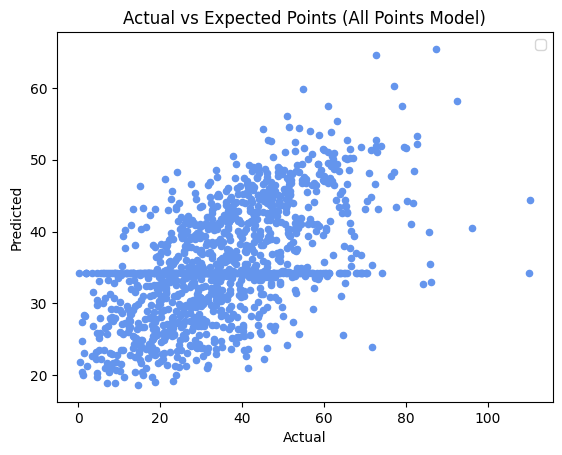

Model Performance - Bat + Bowl Fantasy Points Model
MAE - Bat + Bowl: 11.057135581414736
MAPE - Bat + Bowl: 0.8032000943691099
RMSE - Bat + Bowl: 14.203166373444011
R2 - Bat + Bowl: 0.3315930978314815


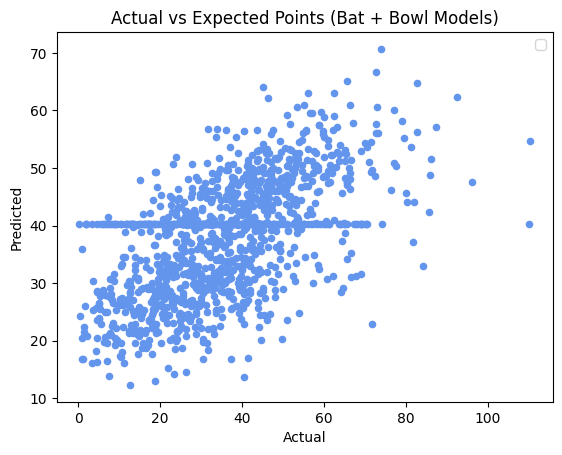

In [39]:
# Model Performance - All Fantasy Points Model
print("Model Performance - All Fantasy Points Model")

model_pred_df = exp_fp_all_pred.copy()
Y_actl = model_pred_df["resp_var"]
Y_pred = model_pred_df["exp_pts"]

# Performance Metrics
mae_all = mean_absolute_error(y_true = Y_actl, y_pred = Y_pred)
mape_all = mean_absolute_percentage_error(y_true = Y_actl, y_pred = Y_pred) 
rmse_all = root_mean_squared_error(y_true = Y_actl, y_pred = Y_pred) 
r2_all = r2_score(y_true = Y_actl, y_pred = Y_pred)

print("MAE - All:", mae_all) 
print("MAPE - All:", mape_all) 
print("RMSE - All:", rmse_all)
print("R2 - All:", r2_all)

# Actual vs Expected Plots
plt.figure()
plt.scatter(Y_actl, Y_pred, s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected Points (All Points Model)")
plt.legend()
plt.show()

# 5c. Residual Analysis
  # Train Residuals
# Y_train_res = pd.DataFrame(Y_train).reset_index(drop=True)
# Y_train_pred = pd.DataFrame(Y_pred_train).reset_index(drop=True)
# Y_train_res['pred'] = Y_train_pred[0]
# Y_train_res['res'] = Y_train_res['resp_var'] - Y_train_res['pred']
# Y_train_res['abs_res'] = abs(Y_train_res['res'])
# train_res = pd.concat([Y_train_res, X_train.reset_index(drop=True)], axis=1)

#   # Plots
# plt.figure()
# plt.scatter(train_res['resp_var'], train_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
# plt.xlabel("Actual")
# plt.ylabel("Absolute Residual")
# plt.title("Actual vs Residual (train)")
# plt.legend()
# plt.show()

# Model Performance - Bat + Bowl Fantasy Points Models
print("Model Performance - Bat + Bowl Fantasy Points Model")

model_pred_df = exp_fp_bat_bwl_pred.copy()
Y_actl = model_pred_df["resp_var"]
Y_pred = model_pred_df["exp_pts"]

# Performance Metrics
mae_bat_bwl = mean_absolute_error(y_true = Y_actl, y_pred = Y_pred)
mape_bat_bwl = mean_absolute_percentage_error(y_true = Y_actl, y_pred = Y_pred) 
rmse_bat_bwl = root_mean_squared_error(y_true = Y_actl, y_pred = Y_pred) 
r2_bat_bwl = r2_score(y_true = Y_actl, y_pred = Y_pred)

print("MAE - Bat + Bowl:", mae_bat_bwl) 
print("MAPE - Bat + Bowl:", mape_bat_bwl) 
print("RMSE - Bat + Bowl:", rmse_bat_bwl)
print("R2 - Bat + Bowl:", r2_bat_bwl)

# Actual vs Expected Plots
plt.figure()
plt.scatter(Y_actl, Y_pred, s = 20, color="cornflowerblue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected Points (Bat + Bowl Models)")
plt.legend()
plt.show()

# 5c. Residual Analysis
  # Train Residuals
# Y_train_res = pd.DataFrame(Y_train).reset_index(drop=True)
# Y_train_pred = pd.DataFrame(Y_pred_train).reset_index(drop=True)
# Y_train_res['pred'] = Y_train_pred[0]
# Y_train_res['res'] = Y_train_res['resp_var'] - Y_train_res['pred']
# Y_train_res['abs_res'] = abs(Y_train_res['res'])
# train_res = pd.concat([Y_train_res, X_train.reset_index(drop=True)], axis=1)

#   # Plots
# plt.figure()
# plt.scatter(train_res['resp_var'], train_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
# plt.xlabel("Actual")
# plt.ylabel("Absolute Residual")
# plt.title("Actual vs Residual (train)")
# plt.legend()
# plt.show()